In [1]:
pip install yfinance #yahoo finance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
stocks = [
    "RELIANCE.NS",      # Energy
    "TCS.NS",           # IT
    "INFY.NS",          # IT
    "HDFCBANK.NS",      # Banking
    "ICICIBANK.NS",     # Banking
    "HINDUNILVR.NS",    # FMCG
    "SUNPHARMA.NS",     # Pharma
    "MARUTI.NS",        # Automobile
    "LT.NS",            # Infrastructure
    "BHARTIARTL.NS"     # Telecom
] #choosing large cap indian stocks from NSE

In [4]:
data=yf.download(
    stocks,
    start="2019-01-01",
    end="2024-01-01"
)
print(data.head()) #print whatever yahoo provides

/tmp/ipykernel_6692/3478946340.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(
[*********************100%***********************]  10 of 10 completed

Price              Close                                                     \
Ticker     BHARTIARTL.NS HDFCBANK.NS HINDUNILVR.NS ICICIBANK.NS     INFY.NS   
Date                                                                          
2019-01-01    280.425446  496.185883   1591.314575   350.957031  541.725830   
2019-01-02    274.413177  491.658508   1576.735962   351.777161  544.983948   
2019-01-03    275.159241  487.800964   1580.093872   350.474609  545.065674   
2019-01-04    283.014679  489.106049   1574.173828   352.356049  538.467529   
2019-01-07    285.208923  489.845154   1577.045654   354.768127  547.142700   

Price                                                                       \
Ticker            LT.NS    MARUTI.NS RELIANCE.NS SUNPHARMA.NS       TCS.NS   
Date                                                                         
2019-01-01  1283.006470  7004.461914  496.196381   402.755890  1561.000854   
2019-01-02  1268.413696  6808.712402  489.733887   408.

In [5]:
prices = data["Close"]
print(prices.head())

Ticker      BHARTIARTL.NS  HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS  \
Date                                                                  
2019-01-01     280.425446   496.185883    1591.314575    350.957031   
2019-01-02     274.413177   491.658508    1576.735962    351.777161   
2019-01-03     275.159241   487.800964    1580.093872    350.474609   
2019-01-04     283.014679   489.106049    1574.173828    352.356049   
2019-01-07     285.208923   489.845154    1577.045654    354.768127   

Ticker         INFY.NS        LT.NS    MARUTI.NS  RELIANCE.NS  SUNPHARMA.NS  \
Date                                                                          
2019-01-01  541.725830  1283.006470  7004.461914   496.196381    402.755890   
2019-01-02  544.983948  1268.413696  6808.712402   489.733887    408.794189   
2019-01-03  545.065674  1241.274658  6748.849121   483.691925    405.124786   
2019-01-04  538.467529  1235.090454  6777.469727   486.303406    402.988098   
2019-01-07  547.142700  1231

In [6]:
#in case any company's ipo happened later to remove NaN value i make it null or 0
print(prices.isnull().sum())
prices=prices.dropna()

Ticker
BHARTIARTL.NS    0
HDFCBANK.NS      0
HINDUNILVR.NS    0
ICICIBANK.NS     0
INFY.NS          0
LT.NS            0
MARUTI.NS        0
RELIANCE.NS      0
SUNPHARMA.NS     0
TCS.NS           0
dtype: int64


In [7]:
#to calculate daily return %
returns=prices.pct_change()
returns=returns.dropna() #since first day has no previous day
print(returns.head())

Ticker      BHARTIARTL.NS  HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS   INFY.NS  \
Date                                                                            
2019-01-02      -0.021440    -0.009124      -0.009161      0.002337  0.006014   
2019-01-03       0.002719    -0.007846       0.002130     -0.003703  0.000150   
2019-01-04       0.028549     0.002675      -0.003747      0.005368 -0.012105   
2019-01-07       0.007753     0.001511       0.001824      0.006846  0.016111   
2019-01-08       0.013233    -0.008323      -0.007899      0.033859 -0.002456   

Ticker         LT.NS  MARUTI.NS  RELIANCE.NS  SUNPHARMA.NS    TCS.NS  
Date                                                                  
2019-01-02 -0.011374  -0.027946    -0.013024      0.014992  0.010773  
2019-01-03 -0.021396  -0.008792    -0.012337     -0.008976 -0.012141  
2019-01-04 -0.004982   0.004241     0.005399     -0.005274 -0.012158  
2019-01-07 -0.003062   0.017631     0.005552     -0.006915  0.011216  
2019-0

In [8]:
# to calculate annual returns
mean_daily_returns=returns.mean() #average daily return for each stock
annual_returns=mean_daily_returns*252 # taking 252 trading days excluding weekends and bank holidays
print(annual_returns)

Ticker
BHARTIARTL.NS    0.310574
HDFCBANK.NS      0.138283
HINDUNILVR.NS    0.122563
ICICIBANK.NS     0.264253
INFY.NS          0.238744
LT.NS            0.240876
MARUTI.NS        0.124035
RELIANCE.NS      0.239133
SUNPHARMA.NS     0.267231
TCS.NS           0.194813
dtype: float64


In [9]:
#Covariance matrix
cov_matrix=returns.cov()*252
print(cov_matrix)

Ticker         BHARTIARTL.NS  HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS  \
Ticker                                                                   
BHARTIARTL.NS       0.094933     0.027801       0.016744      0.034573   
HDFCBANK.NS         0.027801     0.072180       0.018346      0.057064   
HINDUNILVR.NS       0.016744     0.018346       0.055632      0.021959   
ICICIBANK.NS        0.034573     0.057064       0.021959      0.108210   
INFY.NS             0.022668     0.026013       0.020257      0.029944   
LT.NS               0.030062     0.039941       0.019615      0.051457   
MARUTI.NS           0.030838     0.036815       0.026796      0.049368   
RELIANCE.NS         0.027242     0.035143       0.023706      0.041080   
SUNPHARMA.NS        0.022732     0.017813       0.016295      0.025500   
TCS.NS              0.018278     0.020451       0.018158      0.024041   

Ticker          INFY.NS     LT.NS  MARUTI.NS  RELIANCE.NS  SUNPHARMA.NS  \
Ticker                              

In [10]:
#Portfolio weights (a combination strategy i picked at random)
num_stocks=len(stocks) #number of stocks
weights=np.random.random(num_stocks) # generate random weights
weights/=np.sum(weights) # normalise so they sum up to 1
print(weights)

[0.0364826  0.19541994 0.03872713 0.21974412 0.02215228 0.12984641
 0.13858776 0.08641658 0.07953813 0.05308506]


In [11]:
#Portfolio return
portfolio_return = np.sum(weights * annual_returns)
print(f"Expected Annual Return: {portfolio_return:.2%}")

Expected Annual Return: 20.72%


In [12]:
# calculating portfolio volatility (risk)
portfolio_volatility = np.sqrt(
    np.dot(weights.T, np.dot(cov_matrix, weights))
)

print(f"Portfolio Volatility: {portfolio_volatility:.2%}")

Portfolio Volatility: 20.73%


In [13]:
# assuming a 6% annual risk-free rate
risk_free_rate = 0.06

# Calculate Sharpe Ratio
sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Sharpe Ratio: 0.71


In [14]:
# using monte carlo simulation for 50k portfolios
num_portfolios = 50000

# storing results
portfolio_returns = []
portfolio_volatilities = []
portfolio_sharpe = []
portfolio_weights = []

for i in range(num_portfolios):

    # generating random weights
    weights = np.random.random(num_stocks)
    weights /= np.sum(weights)

    # portfolio veturn
    portfolio_return = np.sum(weights * annual_returns)

    # portfolio volatility
    portfolio_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix, weights))
    )

    # sharpe ratio
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

    # storing results
    portfolio_returns.append(portfolio_return)
    portfolio_volatilities.append(portfolio_volatility)
    portfolio_sharpe.append(sharpe_ratio)
    portfolio_weights.append(weights)

In [15]:
#converting results to dataframe
results = pd.DataFrame({
    "Return": portfolio_returns,
    "Volatility": portfolio_volatilities,
    "Sharpe Ratio": portfolio_sharpe
})

results["Weights"] = portfolio_weights

results.head()

,Return,Volatility,Sharpe Ratio,Weights
0,0.219005,0.180013,0.883297,"[0.23988225244584432, 0.0111085013207347, 0.24..."
1,0.221646,0.177215,0.912149,"[0.13952860677877318, 0.09142353294610565, 0.1..."
2,0.211975,0.206269,0.736779,"[0.0777228205848243, 0.2032042577259393, 0.031..."
3,0.190653,0.190784,0.684822,"[0.0010172023658833241, 0.15050130568485096, 0..."
4,0.227810,0.189479,0.885637,"[0.02860512552346744, 0.04785693985031041, 0.0..."


In [16]:
#finding best portfolio
max_sharpe_idx = results["Sharpe Ratio"].idxmax()
optimal_portfolio = results.loc[max_sharpe_idx]

print("Optimal Portfolio")
print(optimal_portfolio)
#portflio i would recommend if goal is maximum risk adjusted return

Optimal Portfolio
Return                                                   0.254136
Volatility                                               0.188601
Sharpe Ratio                                             1.029344
Weights         [0.2416749080334819, 0.0029711886661671926, 0....
Name: 44320, dtype: object


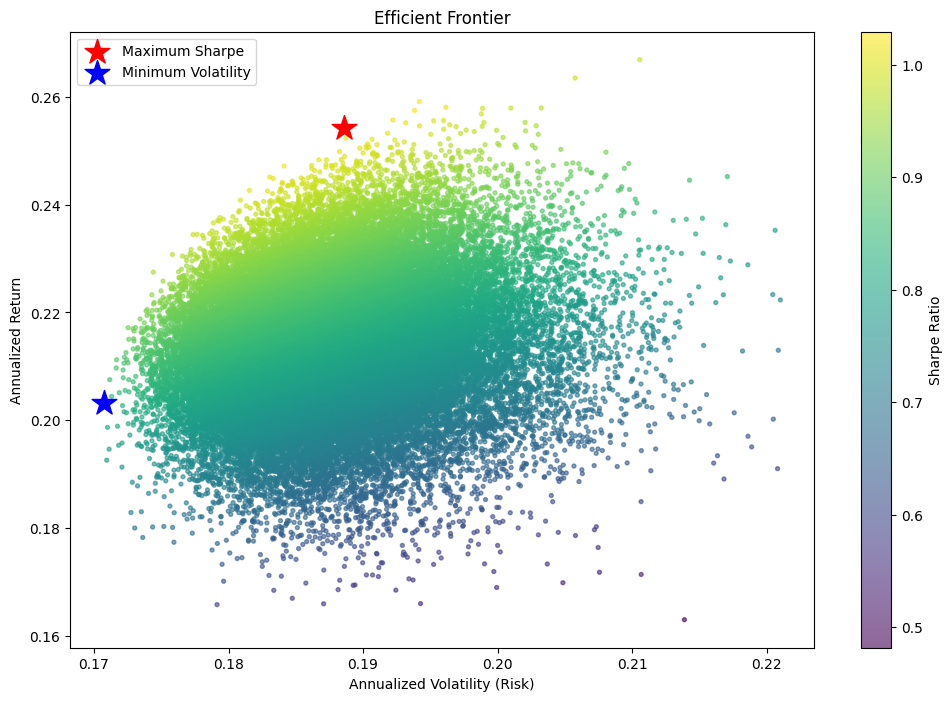

In [17]:
import matplotlib.pyplot as plt

#main plot
plt.figure(figsize=(12,8))

# finding minimum volatility portfolio
min_volatility_idx = results["Volatility"].idxmin()
min_volatility_portfolio = results.loc[min_volatility_idx]

plt.scatter(
    results["Volatility"],
    results["Return"],
    c=results["Sharpe Ratio"],
    cmap="viridis",
    alpha=0.6,
    s=8
)

plt.colorbar(label="Sharpe Ratio")

plt.scatter(
    optimal_portfolio["Volatility"],
    optimal_portfolio["Return"],
    color="red",
    marker="*",
    s=350,
    label="Maximum Sharpe"
)

plt.scatter(
    min_volatility_portfolio["Volatility"],
    min_volatility_portfolio["Return"],
    color="blue",
    marker="*",
    s=350,
    label="Minimum Volatility"
)

plt.title("Efficient Frontier")
plt.xlabel("Annualized Volatility (Risk)")
plt.ylabel("Annualized Return")
plt.legend()

plt.show()

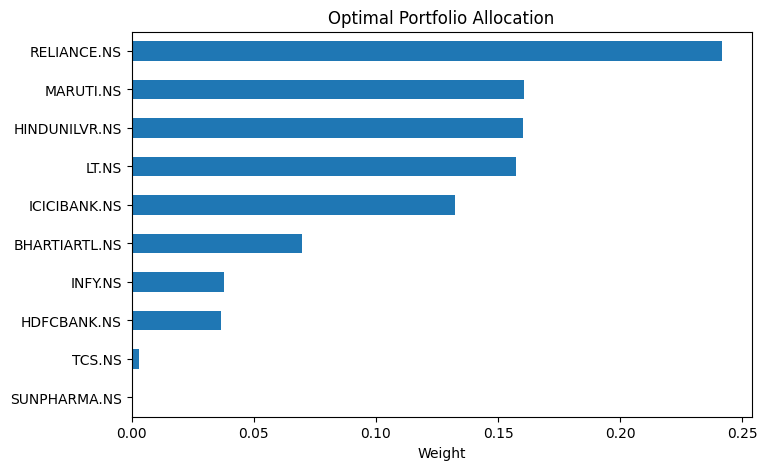

In [18]:
#plot optimal portflio allocation
optimal_weights = pd.Series(
    optimal_portfolio["Weights"],
    index=stocks
)

plt.figure(figsize=(8,5))

optimal_weights.sort_values().plot(
    kind="barh"
)

plt.title("Optimal Portfolio Allocation")
plt.xlabel("Weight")

plt.show()

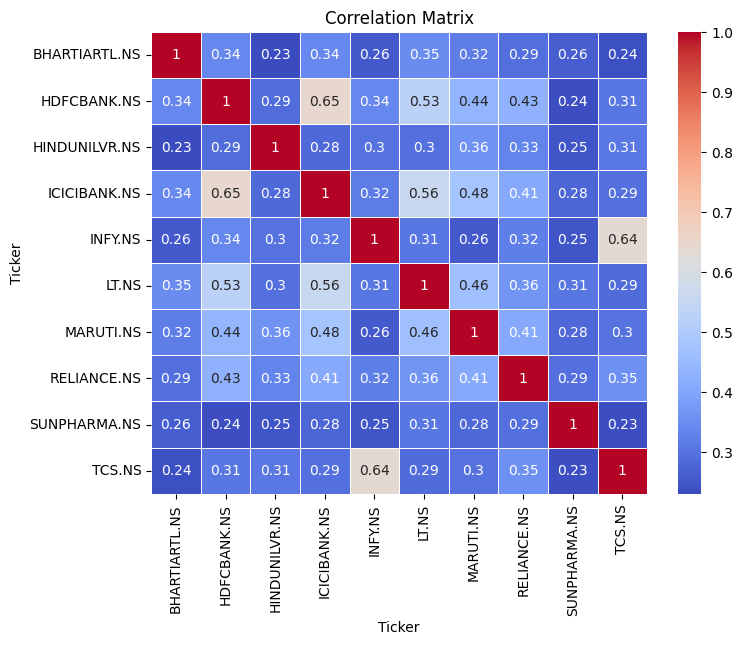

In [19]:
#correlation heatmap
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

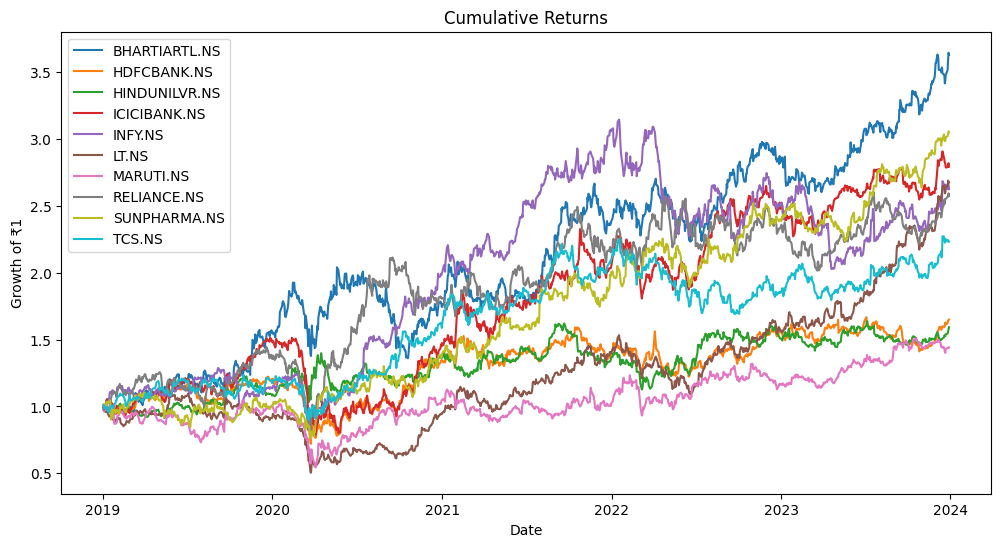

In [20]:
#cumulative returns
cumulative_returns = (1 + returns).cumprod()

plt.figure(figsize=(12,6))

for stock in cumulative_returns.columns:
    plt.plot(
        cumulative_returns.index,
        cumulative_returns[stock],
        label=stock
    )

plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")

plt.legend()

plt.show()

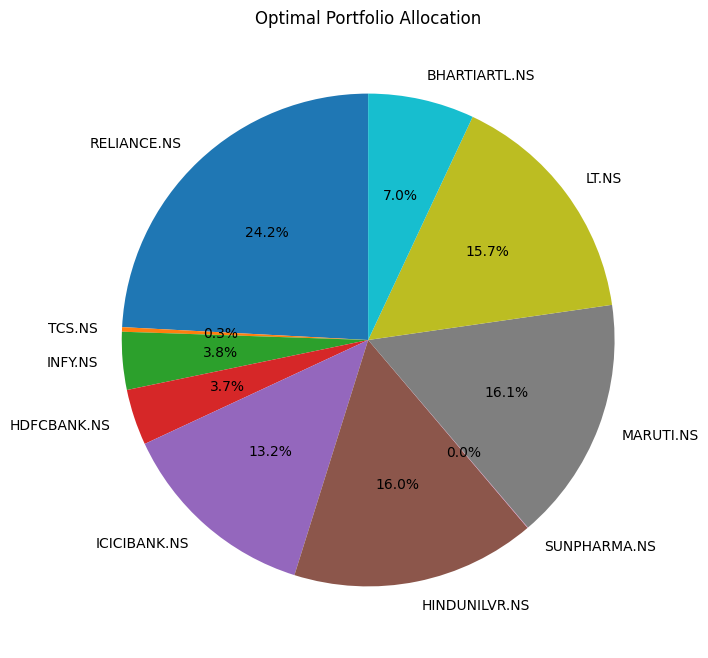

In [21]:
#portfolio weight pie chart
plt.figure(figsize=(8,8))

plt.pie(
    optimal_weights,
    labels=stocks,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Optimal Portfolio Allocation")

plt.show()

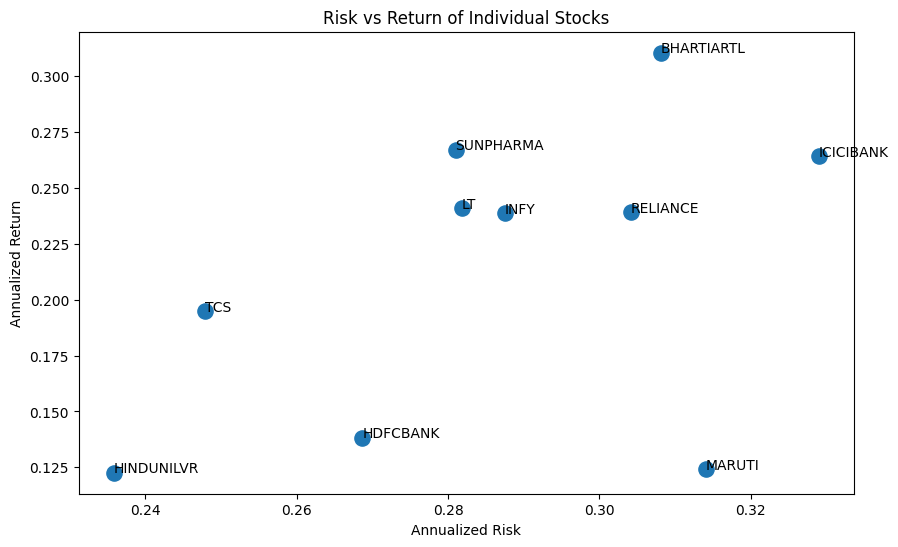

In [22]:
#risk vs return for individual stocks
individual_returns = annual_returns
individual_risk = returns.std() * np.sqrt(252)

plt.figure(figsize=(10,6))

plt.scatter(individual_risk, individual_returns, s=120)

for stock in stocks:
    plt.annotate(
        stock.replace(".NS",""),
        (
            individual_risk[stock],
            individual_returns[stock]
        )
    )

plt.xlabel("Annualized Risk")
plt.ylabel("Annualized Return")
plt.title("Risk vs Return of Individual Stocks")

plt.show()

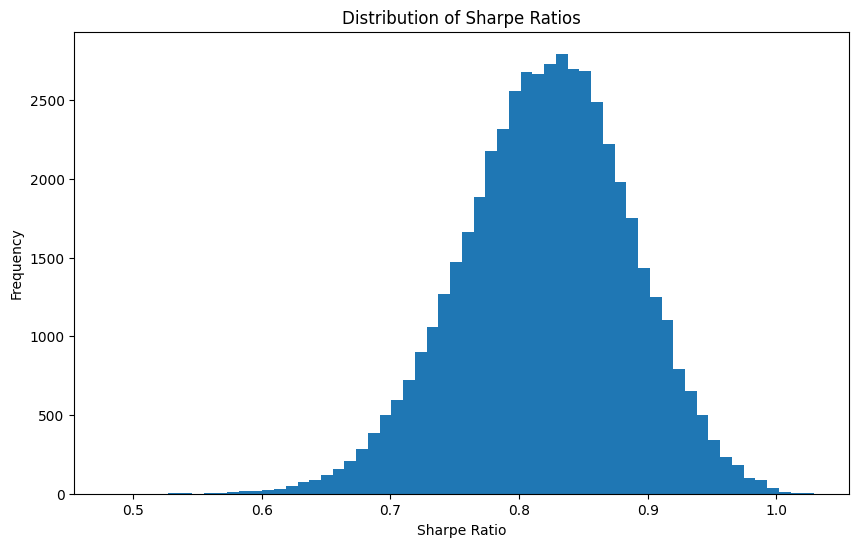

In [23]:
#sharpe ratio distribution
plt.figure(figsize=(10,6))

plt.hist(
    results["Sharpe Ratio"],
    bins=60
)

plt.title("Distribution of Sharpe Ratios")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Frequency")

plt.show()